[nama-link-Tableau](https://www.google.com/) #TODO

---
# Introduction

---

================================================= <br>
**Order-Guardian** (*Data Analyst notebook*)

FTDS-RMT-051 Group 1 <br>
- Evan Jules
- Fernando Namora
- Kevin Hadi Sutanto
- Maulana Malik Fajri

This notebook built to data exploration, preprocessing, and analyzing cancellation rate from ecommerce dataset. <br>
================================================= <br>


## Dataset Information:

Source of Dataset: [Brazilian-ECommerce-Public-Dataset-by-Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

### Dataset 1: `modelling_df`
> Order-item level dataset resulted from merge between raw datas. Each row represent one product from a single order. One order can have multiple rows for each product.

| Column | Description |
| --- | --- |
| `order_id` | order identifier |
| `customer_id` | key to the orders dataset where each order has unique customer_id |
| `order_status` | status of the order (delivered, shipped, canceled, etc) |
| `order_purchase_timestamp` | purchase timestamp of a single order |
| `order_approved_at` | payment approval timestamp of a single order |
| `order_delivered_carrier_date` | order posting timestamp when handled to the logistic partner |
| `order_delivered_customer_date` | actual delivery date to the customer of a single order |
| `order_estimated_delivery_date` | estimated delivery date to the customer of a single order |
| `order_item_id` | sequential number identifying number of items included in the same order |
| `product_id` | product unique identifier |
| `shipping_limit_date` | seller shipping limit date for handling the order over to the logistic partner |
| `price` | item price of product from single order |
| `freight_value` | item freigth value (if an order has more than one item, the freight value is splitted between items) |
| `payment_sequential` | sequence of customer payment method (can be more than one payment method) of a single order |
| `payment_type` | method of payment chosen by the customer of a single order |
| `payment_installments` | number of installments for payment chosen by the customer of a single order |
| `payment_value` | transaction value of a single order for eaach payment sequential |
| `customer_unique_id` | unique identifier of a customer |
| `customer_zip_code_prefix` | first five digits of customer zip code |
| `customer_city` | customer city name |
| `customer_state` | customer state |
| `product_name_lenght` | number of characters extracted from the product name |
| `product_description_lenght` | number of characters extracted from the product description |
| `product_photos_qty` | number of product published photos |
| `product_weight_g` | product weight measured in grams |
| `product_length_cm` | product length measured in centimeters |
| `product_height_cm` | product height measured in centimeters |
| `product_width_cm` | product width measured in centimeters |
| `is_canceled` | status whether an order is canceled or not (`1` = canceled orders, `0` = non-canceled orders) |

### Dataset 2: `order_agg_modeling`
> The dataset that has been aggregated to be in a grain version. One row represent one orders, without breakdown of product from a single order.

| Column | Description |
| --- | --- |
| `order_id` | order identifier |
| `customer_id` | key to the orders dataset where each order has unique customer_id |
| `order_status` | status of the order (delivered, shipped, canceled, etc) |
| `order_purchase_timestamp` | purchase timestamp of a single order |
| `order_approved_at` | payment approval timestamp of a single order |
| `order_delivered_carrier_date` | order posting timestamp when handled to the logistic partner |
| `order_delivered_customer_date` | actual delivery date to the customer of a single order |
| `order_estimated_delivery_date` | estimated delivery date to the customer of a single order |
| `total_items` | number of products of a single order |
| `total_order_value` | total price of products of a single order |
| `total_freight` | freigth value of a single order |
| `avg_item_price` | average price of products of a single order |
| `payment_type` | method of payment chosen by the customer of a single order |
| `max_installments` | maximum number of installments for payment chosen by the customer of a single order |
| `total_payment_value` | total transaction value of a single order |
| `customer_unique_id` | unique identifier of a customer |
| `customer_zip_code_prefix` | first five digits of customer zip code |
| `customer_city` | customer city name |
| `customer_state` | customer state |
| `is_canceled` | status whether an order is canceled or not (`1` = canceled orders, `0` = non-canceled orders) |

---

## Background of the Study:

Indonesia's digital economy continues to grow rapidly, with e-commerces as the main contributor to national Gross Merchandise Value (GMV). According to the *Google, Temasek, and Bain & Company report* (e-Conomy SEA 2025), Indonesia's e-commerce GMV reached approximately **US$71 billions**, growing at double-digit rates annually. This rapid growth presents significant operational challenges for retailers and online platforms. As transaction volumes increase across multiple cities, online retailers must handle thousands of daily orders across various product categories, shipping methods, and payment options. However, this rapid growth also have one of the challenges of operational risks, that is **order cancellations**.

Order cancellations can negatively impact business performance in several ways such as lost revenue opportunities, inefficient inventory allocation, inaccuraate demand planning, etc. The impact becomes more critical in COD (Cash on Delivery) transactions, where cancelled orders may generate additional logistics and reverse-shipping costs. Also geographic factors and shipping options can further influence order completion rates as well. These issues directly affect revenue realization and operational efficiency. Therefore, transactional data must be properly structured and analyzed to better understand cancellation patterns and support data-driven decision-making.

Retail companies store detailed order transactional data, including order value, product categories, shipping methods, payment types, geographic location, and order timestamps. These features have meaningful signals that can help explain cancellation behavior. Rather than analyzing cancellations only descriptively, companies need a more structured and predictive approach to identify high-risk orders earlier and manage operational risk more effectively.

Source: [e-Conomy-SEA-2025-ekonomi-digital-Indonesia](https://blog.google/intl/id-id/company-news/outreach-initiatives/e-conomy-sea-2025-ekonomi-digital-indonesia-mendekati-gmv-us100-miliar)

---

## Problem Statement and Objective:

Despite having rich historical transactional data, the company currently analyzes cancellations only in a descriptive and reactive manner. There is no structured analytical framework to systematically identify patterns and risk factors associated with cancelled orders. Resulted operational decisions are made **after** cancellation occur, rather than being informed by proactive insights.

Therefore, the **historical order transactional data** will be analyzed to identify **patterns and risk factors associated with cancelled orders** through structured data analysis. The problem can be translated into the following business questions:

1. What is the overall cancellation rate in the historical dataset?
2. How are cancellations distributed across customers? 
3. How is the cancellation rate for each product? 
4. Which customer segments are most likely to cancel their orders based on transaction history?
5. When do order cancellations most frequently occur?
6. Where do order cancellation most frequently occur, based on customer location?
7. Which features show the strongest relationship with order cancellations?
8. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?

---
# Import Library

---

In [103]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# For ignore warnings from pandas
import warnings
warnings.filterwarnings("ignore")

---
# Data Loading

---

First, we will load the `modelling_df` data, that is constructed at the **order-item level** which:
- 1 row represents 1 product item within an order
- A single `order_id` may appear multiple times if the order contains multiple products

This dataset will assign to the variable `df`:

In [55]:
# Since the data is located on directory '../data/cleaned' from DE part:
df = pd.read_csv('../data/cleaned/modelling_df_v0_1.csv', index_col=0) # use index column
backup_df = df.copy() # for backup of changes in original df

# Check the summary with info method()
df.info()

pd.set_option('display.max_columns', None) # to see all columns
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 117784 entries, 0 to 118433
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117784 non-null  object 
 1   customer_id                    117784 non-null  object 
 2   order_status                   117784 non-null  object 
 3   order_purchase_timestamp       117784 non-null  object 
 4   order_approved_at              117608 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  117784 non-null  object 
 8   order_item_id                  117597 non-null  float64
 9   product_id                     117597 non-null  object 
 10  shipping_limit_date            117597 non-null  object 
 11  price                          117597 non-null  float64
 12  freight_value                  1175

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,40.0,268.0,4.0,500.0,19.0,8.0,13.0,0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,29.0,178.0,1.0,400.0,19.0,13.0,19.0,0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,46.0,232.0,1.0,420.0,24.0,19.0,21.0,0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,2017-11-23 19:45:59,45.00,27.20,1.0,credit_card,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59.0,468.0,3.0,450.0,30.0,10.0,20.0,0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2018-02-19 20:31:37,19.90,8.72,1.0,credit_card,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,38.0,316.0,4.0,250.0,51.0,15.0,15.0,0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,060cb19345d90064d1015407193c233d,2017-07-13 22:10:13,147.90,27.36,1.0,credit_card,6.0,175.26,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,0
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,a1804276d9941ac0733cfd409f5206eb,2017-04-19 13:25:17,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
9,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,4520766ec412348b8d4caa5e8a18c464,2017-05-22 13:22:11,59.99,15.17

Second, we will also load the `order_agg_modeling` data, that constructed of aggregated of raw data, for each orders. This is to further analyze whether we will use the **order-item level** or **order level** only for the analysis of cancellation rate further. This dataset will be assign to the variable `df_agg`:

In [56]:
# Aggregated data also located in same directory '../data/cleaned' from DE part:
df_agg = pd.read_csv('../data/cleaned/order_agg_modeling_v0_1.csv', index_col=0) # use index column
backup_df_agg = df_agg.copy() # for backup of changes in original df_agg

# Check the summary with info method()
df_agg.info()

df_agg.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 98832 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98832 non-null  object 
 1   customer_id                    98832 non-null  object 
 2   order_status                   98832 non-null  object 
 3   order_purchase_timestamp       98832 non-null  object 
 4   order_approved_at              98672 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  98832 non-null  object 
 8   total_items                    98660 non-null  float64
 9   total_order_value              98660 non-null  float64
 10  total_freight                  98660 non-null  float64
 11  avg_item_price                 98660 non-null  float64
 12  payment_type                   98831 non-null  obje

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,29.99,voucher,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,118.70,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1.0,147.90,27.36,147.90,credit_card,175.26,6.0,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00,1.0,49.90,16.05,49.90,credit_card,65.95,1.0,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1.0,59.99,15.17,59.99,credit_card,75.16,3.0,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1.0,19.90,16.05,19.90,boleto,35.95,1.0,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1.0,149.99,19.77,149.99,credit_card,169.76,1.0,299905e3934e9e181bfb2e164dd4b4f8,18075,sorocaba,SP,0


Note that above data `df` and `df_agg` have some missing values. These will be handle on the next process later.

If we look out for how many orders that comes from each customer:

In [57]:
df.customer_id.value_counts()

customer_id
270c23a11d024a44c896d1894b261a83    63
13aa59158da63ba0e93ec6ac2c07aacb    38
9af2372a1e49340278e7c1ef8d749f34    29
92cd3ec6e2d643d4ebd0e3d6238f69e2    26
63b964e79dee32a3587651701a2b8dbf    24
                                    ..
741a12b94b48a426f2cbd87b83a62c29     1
7fb28b72559f15550a82e040b117dcc6     1
d75f7a65c23672520fa4dc4125443ff9     1
6a2896a95ecb9df4c195ac3ba4139cf7     1
edb027a75a1449115f6b43211ae02a24     1
Name: count, Length: 98832, dtype: int64

Note that there are some customers with multiple orders on the dataset. Perhaps there may be multiple cancelled order for each customer that later we will observed.

---
# Data Cleaning
---

## Missing Values on `df`:

In [58]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     1424
order_delivered_customer_date    2747
order_estimated_delivery_date       0
order_item_id                     187
product_id                        187
shipping_limit_date               187
price                             187
freight_value                     187
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
product_name_lenght              1885
product_description_lenght       1885
product_photos_qty               1885
product_weight_g                  207
product_length_cm                 207
product_heig

We can categorize above missing values as follows:
- The missing values on date columns (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`)
- Missing on order items data (`order_item_id`, `product_id`, `shipping_limit_date`, `price`, `freight_value`)
- Payment data missing (`payment_sequential`, `payment_type`, `payment_installments`, `payment_value`)
- Missing of product details (`product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`)

Checking for each category:

### Missing on Date Columns:

In [59]:
df_date = df[[
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]]
df_date[df_date.isna().any(axis=1)]

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
8,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
51,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
125,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
155,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
192,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...
118081,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00
118124,2018-02-17 14:31:22,2018-02-20 07:11:31,2018-02-20 19:18:58,NaN,2018-03-14 00:00:00
118237,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
118286,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00


Note that, some of the missing values above are comes from `order_delivered_customer_date`. In this project, we concerned for the cancellation rate and later want to predict whether the order will be cancelled or not. In the future, we will notify the warning of such order will be cancelled **prior the order approved by the system**, let alone the order delivered to the customer. So, all of the date columns above **except** `order_purchase_timestamp` will not available in real scenario, or if available will not be used. Therefore, following primary objective of this project, we choose to drop all date columns **except** `order_purchase_timestamp`:

In [60]:
df = df.drop(columns=[
    'order_approved_at', 'order_delivered_carrier_date', 
    'order_delivered_customer_date', 'order_estimated_delivery_date'
], axis=1)

### Missing on Order Items Columns:

First, we will check all data where `order_item_id` missing:

In [61]:
missing_order_items = df[df['order_item_id'].isna()]
missing_order_items

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
1352,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,NaN,NaN,1.0,not_defined,1.0,0.00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2128,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,191.46,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2218,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,NaN,NaN,1.0,boleto,1.0,139.96,c219f4ac1bc7f1aea33e6ab8885831e8,68742,castanhal,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2415,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,66.44,a8dd81392e5eee5d979c629a76abec2a,13059,campinas,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2570,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,2.0,72.90,29dc4aeff866d6a940c471a3ea4faef0,5752,sao paulo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116292,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,1.0,157.13,40d1c2a6b8ac6ccc102d473ff51cc46d,29156,cariacica,ES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
117179,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,NaN,NaN,1.0,credit_card,1.0,280.20,aa75afb965e89078d8681fe33aaaeded,12940,atibaia,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
117771,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,54.42,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,NaN,NaN,1.0,voucher,1.0,63.89,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


If we check other order items columns as well:

In [62]:
cols_to_check = [
    'product_id','shipping_limit_date',
    'price','freight_value'
]

missing_order_items[cols_to_check].isna().all(axis=1).value_counts()

True    187
Name: count, dtype: int64

Hence, all columns of order items that is `order_item_id`, `product_id`, `shipping_limit_date`, `price`, and `freight_value` all simultaneously missing for the same `order_id`.

In [63]:
order_id_missing_order_items = missing_order_items['order_id'].unique().tolist()

check_original = df[
    (df['order_id'].isin(order_id_missing_order_items)) &
    (df['order_item_id'].notna())
]

check_original.shape

(0, 25)

Based on above output, we can see that all 172 `order_id` does not have all order items columns at all. Before deciding any treatment, we will check the distribution of `is_canceled` for these orders to understand whether this is a data issue or a business process event (that is canceled orders).

In [64]:
missing_order_items['is_canceled'].value_counts()

is_canceled
1    179
0      8
Name: count, dtype: int64

From the distribution above, we observe that most (or all) of these orders
are labeled as `is_canceled`. This indicates that the absence of order item column information is not due to random missing values, but likely due to the order was canceled before item fulfillment was recorded. Therefore, these rows represent structurally missing rather than incomplete data.

For further exploratory analysis (correlation analysis and aggregation), we will temporarily impute these missing order item fields.

- Imputation performed only for EDA purposes, not imply that htese orders contain actual items
- FIlling identifier columns with label `"no_item"`, numerical columns with 0 (structural absence), and datetime with `NaT`

In [65]:
missing_index = missing_order_items.index

# Numeric columns → structural zero
df.loc[missing_index, 'order_item_id'] = 0
df.loc[missing_index, 'price'] = 0
df.loc[missing_index, 'freight_value'] = 0

# Categorical
df.loc[missing_index, 'product_id'] = 'no_item'

# Datetime
df.loc[missing_index, 'shipping_limit_date'] = pd.NaT

In [66]:
df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_item_id                    0
product_id                       0
shipping_limit_date            187
price                            0
freight_value                    0
payment_sequential               3
payment_type                     3
payment_installments             3
payment_value                    3
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_name_lenght           1885
product_description_lenght    1885
product_photos_qty            1885
product_weight_g               207
product_length_cm              207
product_height_cm              207
product_width_cm               207
is_canceled                      0
dtype: int64

Note that column `shipping_limit_date` still missing. However, following same behavior with previous date columns, since we concern before the order approved, this column `shipping_limit_date` should not be available. We will drop this column as well.

In [67]:
df = df.drop(columns=['shipping_limit_date'], axis = 1)

### Missing on Payment Data Columns:

We will check based on column `payment_sequential` first:

In [68]:
missing_payment = df[df['payment_sequential'].isna()]
missing_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
36657,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,1.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0
36658,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0
36659,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,3.0,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,34.0,1036.0,1.0,1000.0,16.0,16.0,16.0,0


In [69]:
# check other column payment data
cols_to_check = [
    'payment_type', 'payment_installments', 'payment_value'
]

missing_payment[cols_to_check].isna().all(axis=1).value_counts()

True    3
Name: count, dtype: int64

Note that, all columns of payment data that is `payment_sequential`, `payment_type`, `payment_installments`, and `payment_value` all simultaneously missing for the same `order_id`. All 3 rows occurred for the `order_id` **bfbd0f9bdef84302105ad712db648a6c**. Also, by checking other columns values, no other columns affected this missingness, hence it is **MCAR** type of missing.

Since payment information represents transactional entity, rows without any payment data not provide meaningful analytical value. We conclude to remove these 3 rows to maintain data integrity for further exploratory analysis, due no partial information can be reasonably imputed.

In [70]:
df = df.dropna(subset=['payment_sequential']) # since other columns follows

### Missing on Product Detail Columns:

We will check based on column `product_name_lenght` first:

In [71]:
missing_product = df[df['product_name_lenght'].isna()]
missing_product

,order_id,customer_id,order_status,order_purchase_timestamp,order_item_id,product_id,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,is_canceled
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,1.0,a1804276d9941ac0733cfd409f5206eb,49.90,16.05,1.0,credit_card,1.0,65.95,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,NaN,NaN,NaN,600.0,35.0,35.0,15.0,0
129,bfe42c22ecbf90bc9f35cf591270b6a7,803ac05904124294f8767894d6da532b,delivered,2018-01-27 22:04:34,1.0,71225f49be70df4297892f6a5fa62171,27.30,15.10,1.0,credit_card,1.0,42.40,34c58672601f2c6d29db7efd1f6bf958,38650,bonfinopolis de minas,MG,NaN,NaN,NaN,200.0,16.0,2.0,11.0,0
221,58ac1947c1a9067b9f416cba6d844a3f,ee8e1d37f563ecc11cc4dcb4dfd794c2,delivered,2017-09-13 09:18:50,1.0,9820e04e332fc450d6fd975befc1bc28,110.00,14.16,1.0,credit_card,5.0,124.16,5cbf29b2dcf212a6a5d864b887238c72,4842,sao paulo,SP,NaN,NaN,NaN,10800.0,40.0,40.0,30.0,0
274,e22b71f6e4a481445ec4527cb4c405f7,1faf89c8f142db3fca6cf314c51a37b6,delivered,2017-04-22 13:48:18,1.0,3bc5164bc7f4be77002d6651da65c98c,22.50,11.74,1.0,credit_card,3.0,34.24,1268b060098ed3f22c2e7c34cc72a1a8,38240,itapagipe,MG,NaN,NaN,NaN,550.0,16.0,11.0,19.0,0
316,a094215e786240fcfefb83d18036a1cd,86acfb656743da0c113d176832c9d535,delivered,2018-02-08 18:56:45,1.0,5a848e4ab52fd5445cdc07aab1c40e48,122.99,9.06,1.0,credit_card,1.0,132.05,f5cb81f98962f7504bef1e75579b6dff,13474,americana,SP,NaN,NaN,NaN,400.0,20.0,12.0,15.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118171,f0dd9af88d8ef5a8e4670fbbedaf19c4,30ddb50bd22ee927ebe308ea3da60735,delivered,2017-09-02 20:38:29,1.0,0c877471e35049402bca235e06cb8063,84.90,15.35,1.0,boleto,1.0,100.25,1d627d8a6e1e33ea8eeeb7a17d998660,11045,santos,SP,NaN,NaN,NaN,10750.0,34.0,20.0,30.0,0
118177,272874573723eec18f23c0471927d778,48e080c8001e92ebea2b64e474f91a60,delivered,2017-12-20 23:10:33,1.0,5a848e4ab52fd5445cdc07aab1c40e48,122.99,9.06,1.0,credit_card,5.0,132.05,da59579685bd771fdd4f90fb50d28cd3,7240,guarulhos,SP,NaN,NaN,NaN,400.0,20.0,12.0,15.0,0
118198,dff2b9b8d7cfc595836945e1443789c3,2436fb2666a65fbacae82532e797cabf,delivered,2018-07-16 12:59:02,1.0,bfa0e398bef2d28bb421d42997982cab,219.99,15.13,1.0,boleto,1.0,235.12,9b352d0736779ff0e21fcbd59a7141b3,22641,rio de janeiro,RJ,NaN,NaN,NaN,3100.0,28.0,20.0,40.0,0
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,0.0,no_item,0.00,0.00,1.0,voucher,1.0,63.89,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


If we check for other column product, only for column `product_description_lenght` and `product_photos_qty` first:

In [72]:
# check other column product detail
cols_to_check = [
    'product_description_lenght', 'product_photos_qty'
]

missing_product[cols_to_check].isna().all(axis=1).value_counts()

True    1885
Name: count, dtype: int64

By above output shows all columns `product_name_lenght`, `product_description_lenght`, and `product_photos_qty` are simulatenously missing for the same `order_id` on all 1885 records on `missing_product` dataframe. Later on EDA question 3, we will further analyze based on products and turns out we will not utilize order-item dataset (based on each order and each product for that order). 

We conclude, the orders without the products information are not concerned (in fact, we will not use all of these columns further). Therefore, all of these records (these 1885 rows) will be dropped and not be used further.

In [73]:
df = df.dropna(subset=['product_name_lenght']) # since other columns follows

# recheck missing
df.isna().sum()

order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_item_id                 0
product_id                    0
price                         0
freight_value                 0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
is_canceled                   0
dtype: int64

Same arguments earlier, we will also drop records where column `product_weight_g` missing (probably other column `product_length_cm`, `product_height_cm`, and `product_width_cm` comes from same order):

In [74]:
df = df.dropna(subset=['product_weight_g']) # since other columns suspected to follows

# recheck missing
df.isna().sum()

order_id                      0
customer_id                   0
order_status                  0
order_purchase_timestamp      0
order_item_id                 0
product_id                    0
price                         0
freight_value                 0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
customer_unique_id            0
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
is_canceled                   0
dtype: int64

By above outputs, now the missing values completely handled for the order-item dataset `df`.

## Missing Values on `df_agg`:

In [75]:
df_agg.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1174
order_delivered_customer_date    2356
order_estimated_delivery_date       0
total_items                       172
total_order_value                 172
total_freight                     172
avg_item_price                    172
payment_type                        1
total_payment_value                 1
max_installments                    1
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
is_canceled                         0
dtype: int64

Note that the patterns of above missing values on the aggregated dataset `df_agg` similar as previous `df`, we can categorize as follows:
- Date columns (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`)
- Order items data (`total_items`, `total_order_value`, `total_freigh`, `avg_item_price`)
- Payment data (`payment_type`, `total_payment_value`, `max_installments`)
> Note that there are no product details data on aggregated dataset, because this aggregated dataset `df_agg` is consructed for order based and not concerning of products from each orders

Therefore, we can use similar arguments with what already done earlier on `df`:

### Missing on Date Columns:

Similar with what explained on `df` part before, we will drop all date columns **except** `order_purchase_timestamp`:

In [76]:
df_agg = df_agg.drop(columns=[
    'order_approved_at', 'order_delivered_carrier_date', 
    'order_delivered_customer_date', 'order_estimated_delivery_date'
], axis=1)

### Missing on Order Items Columns:

Since the order items column from aggregated dataset:
- `total_items` : comes from aggregated column `order_item_id` of non-aggregated dataset
- `total_order_value` : aggregated column `price` of non-aggregated dataset
- `total_freight` : aggregated column `freight_value` of non-aggregated dataset
- `avg_item_price` : aggregated column `price` of non-aggregated dataset

Hence, we can use similar arguments with what explained and performed on `df` dataset earlier. That is, we will temporarily impute the data of these missing (aggregated) order item fields only for further exploratory analysis (correlation and aggregation). With similar impute procedure as earlier:

In [77]:
# Recheck whether those 4 columns missing on the same records or not

missing_order_items = df_agg[df_agg['total_items'].isna()] # check based on column `total_items`
print(f'Number of `total_items` missing: {missing_order_items.shape[0]}')

cols_to_check = [
    'total_order_value','total_freight', 'avg_item_price'
]

missing_order_items[cols_to_check].isna().all(axis=1).value_counts()

Number of `total_items` missing: 172


True    172
Name: count, dtype: int64

Since all of those 4 columns are numerical, we will impute `0` as structural absence (same as what performed on `df` earlier):

In [78]:
# Impute process

missing_index = missing_order_items.index

# Numeric columns → structural zero
df_agg.loc[missing_index, 'total_items'] = 0.0
df_agg.loc[missing_index, 'total_order_value'] = 0.0
df_agg.loc[missing_index, 'total_freight'] = 0.0
df_agg.loc[missing_index, 'avg_item_price'] = 0.0

### Missing on Payment Data Columns:

If we check on column `payment_type` first:

In [79]:
missing_payment = df_agg[df_agg['payment_type'].isna()]
missing_payment

,order_id,customer_id,order_status,order_purchase_timestamp,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,3.0,134.97,8.49,44.99,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0


Note that, this is the same `order_id` **bfbd0f9bdef84302105ad712db648a6c** that earlier found on original dataset `df`. Turns out this same order also reflects with missing values of column `payment_type`, `total_payment_value`, and `max_installments` on aggregated data `df_agg`. With the same arguments, we conclude to drop this record also on `df_agg`:

In [80]:
df_agg = df_agg.dropna(subset=['payment_type']) # since other columns follows

In [81]:
# recheck missing
df_agg.isna().sum()

order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
total_items                 0
total_order_value           0
total_freight               0
avg_item_price              0
payment_type                0
total_payment_value         0
max_installments            0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
is_canceled                 0
dtype: int64

By above outputs, now the missing values completely handled for the aggregated dataset `df_agg` that depicts order based records. We can move further to the next process **Exploratory Data Analysis (EDA)** as main process on this notebook.

---
# Exploratory Data Analysis
---

All of the questions for Exploratory Data Analysis (EDA):

1. What is the overall cancellation rate in the historical dataset?
2. How are cancellations distributed across customers? 
3. How is the cancellation rate for each product? 
4. Which customer segments are most likely to cancel their orders based on transaction history?
5. When do order cancellations most frequently occur?
6. Where do order cancellation most frequently occur, based on customer location?
7. Which features show the strongest relationship with order cancellations?
8. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?

---
## 1. Overall cancellation rate
---


We will analyze the overall cancellation rate on both dataset, the non-aggregated one (`modelling_df` that assigned on variable `df`) also on aggregated dataset (`order_agg_modeling` that assigned on variable `df_agg`).

First the overall cancellation rate on `df`:

In [82]:
# overall cancel rate for `df`
cancel_rate_df= (
    df['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_df

is_canceled
Not Canceled    0.995246
Canceled        0.004754
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

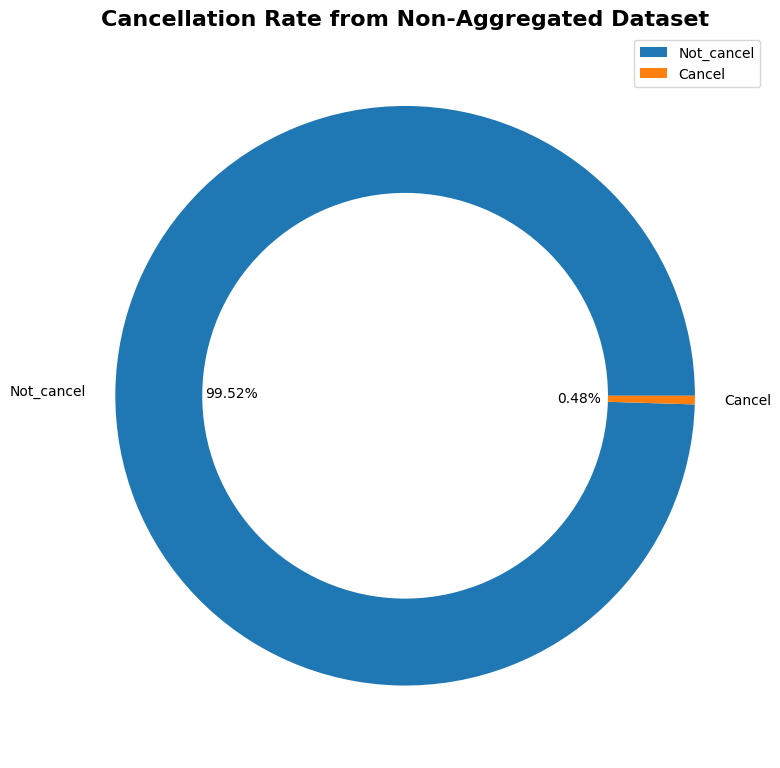

In [122]:
# Pie chart for `df`

fig = plt.figure(figsize=(8, 8))

plt.pie(
    cancel_rate_df.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.2f%%", # show 2 numbers after decimal
    explode=[0,0],
    wedgeprops={'width':0.3}
)

plt.legend(loc='upper right')
plt.title('Cancellation Rate from Non-Aggregated Dataset', fontsize=16, fontweight='bold', y = 1)
plt.tight_layout()
plt.show

This distribution from dataset `modelling_df` shows that most orders are not canceled, with a very low cancellation rate of around 0.48% of total transactions. This indicates that cancellations are not a systemic issue, but rather a relatively rare occurrence likely triggered by certain conditions or factors, such as payment methods, specific customer behavior, or particular transaction situations. 

Since `modelling_df` is structured at the **order-item level** (where one order can appear in multiple rows if it contains multiple products), this result reflects the cancellation distribution at the product-line level. This indicates that our data at this granularity is already **severely imbalanced**.

If we check the aggregated dataset (`order_agg_modeling`) on `df_agg`, where each row represents one unique order:

In [84]:
# overall cancel rate for `df_agg`
cancel_rate_agg= (
    df_agg['is_canceled']
    .value_counts(normalize=True)
    .rename({0: 'Not Canceled', 1: 'Canceled'})
)

cancel_rate_agg

is_canceled
Not Canceled    0.993676
Canceled        0.006324
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

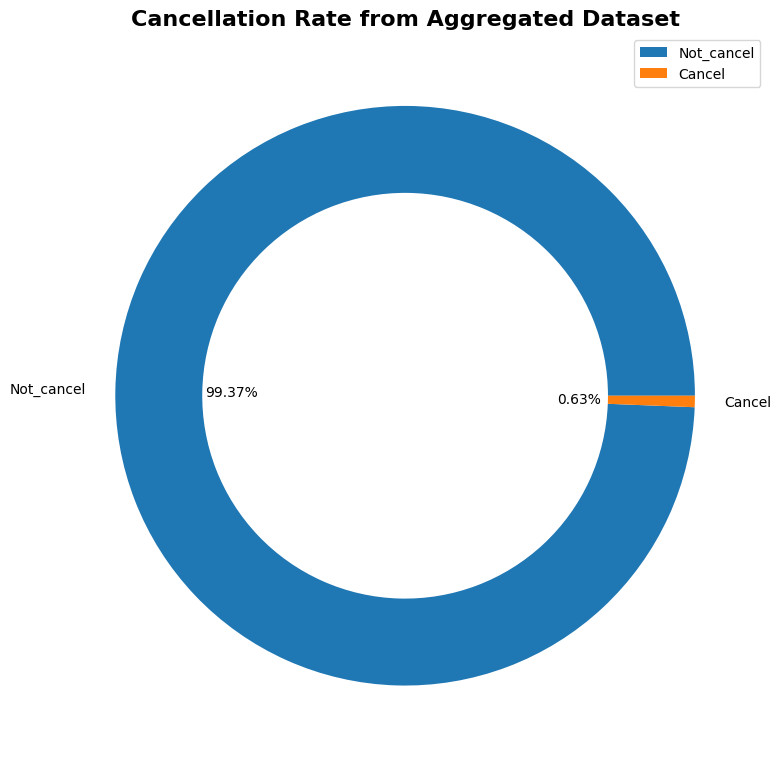

In [121]:
# Pie chart for `df_agg`

fig = plt.figure(figsize=(8, 8))

plt.pie(
    cancel_rate_agg.values,
    labels= ["Not_cancel","Cancel"],
    autopct="%1.2f%%", # show 2 numbers after decimal
    explode=[0,0],
    wedgeprops={'width':0.3}
)

plt.legend(loc='upper right')
plt.title('Cancellation Rate from Aggregated Dataset', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show


Similar to the distribution observed in `modelling_df`, the dataset `order_agg_modeling` also shows that most orders are not canceled, with a cancellation rate of approximately 0.48% (same cancellation rate as well). This further suggests that cancellations are relatively rare events rather than a systemic operational issue.

Since `order_agg_modeling` is structured at the **order level** (where each row represents one unique order), this result reflects the true transaction-level cancellation behavior. This confirms that the target variable remains **severely imbalanced**, even after aggregating from the order-item level to the order-level dataset. 

Additionally, this findings suggests that breaking down transactions into individual product lines may not be necessary for the modeling process. This suggestion will be further evaluated in EDA question 3 later.

---
### 2. Distribution of Cancellation Across Customers
---

First, if we check the distribution on `df`:

In [ ]:
# Group data by `customer_unique_id` to analyze cancellations by customer on Dataset `modelling_df`
number_cancel_percustomer= df.groupby("customer_unique_id")["is_canceled"].sum()
top_5 = number_cancel_percustomer.sort_values(ascending=False).head(5)

In [87]:
# show the top 5 customer cancellations
top_5

customer_unique_id
2592816433dfbb3051af91ba91625de5    9
5b8e2b1579f85b73591611c56267d7f7    6
244024d753ef305e66b7ef97f3813ebd    6
22af178809fa6887af2cc4f7d7bdc0bc    6
9f93044b0156639ec44b7ecfca3b9c31    5
Name: is_canceled, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

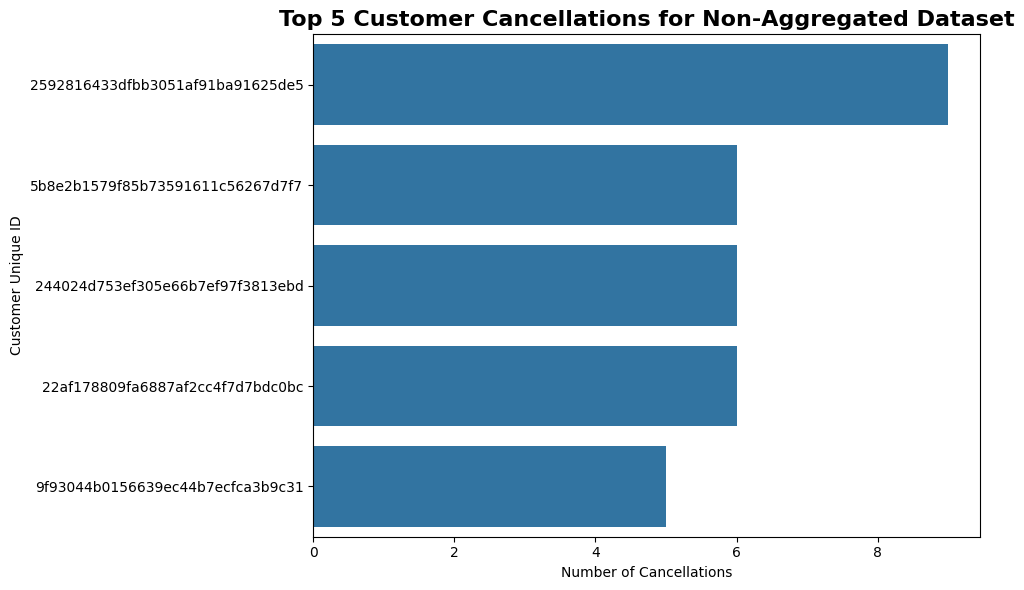

In [120]:
# Visualize the top 5 customer cancellations for `df`

fig = plt.figure(figsize=(10, 6))

sns.barplot(top_5,orient='h')

plt.xlabel('Number of Cancellations')
plt.ylabel('Customer Unique ID')
plt.title('Top 5 Customer Cancellations for Non-Aggregated Dataset', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show

Based on dataset `modelling_df`, show that order cancellations are not evenly distributed across all customers, but are concentrated among a small number of customers with a high frequency of cancellations. Customers with unique ID `2592816433dfbb3051af91ba91625de5` have the highest number of cancellations reached 9 times, while other customers in top 5 were in the range of 5–6 cancellations, indicating the presence of a recurring behavior pattern (repeat cancellation behavior), but not so many number of cancellations.

If we check on `df_agg` also:

In [ ]:
# Group data by `customer_unique_id` to analyze cancellations by customer on Dataset `order_agg_modeling`
num_cancel_percustomer_agg= df_agg.groupby("customer_unique_id")["is_canceled"].sum()
top_5_agg = num_cancel_percustomer_agg.sort_values(ascending=False).head(5)

In [90]:
# show the top 5 customer cancellations
top_5_agg

customer_unique_id
ef0103e9602d12594d19c2b666219bc1    3
ba84da8c159659f116329563a0a981dd    2
391d6062da3dd65b4de4524f28c478de    2
46450c74a0d8c5ca9395da1daac6c120    2
af5454198a97379394cacf676e1e96cb    2
Name: is_canceled, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

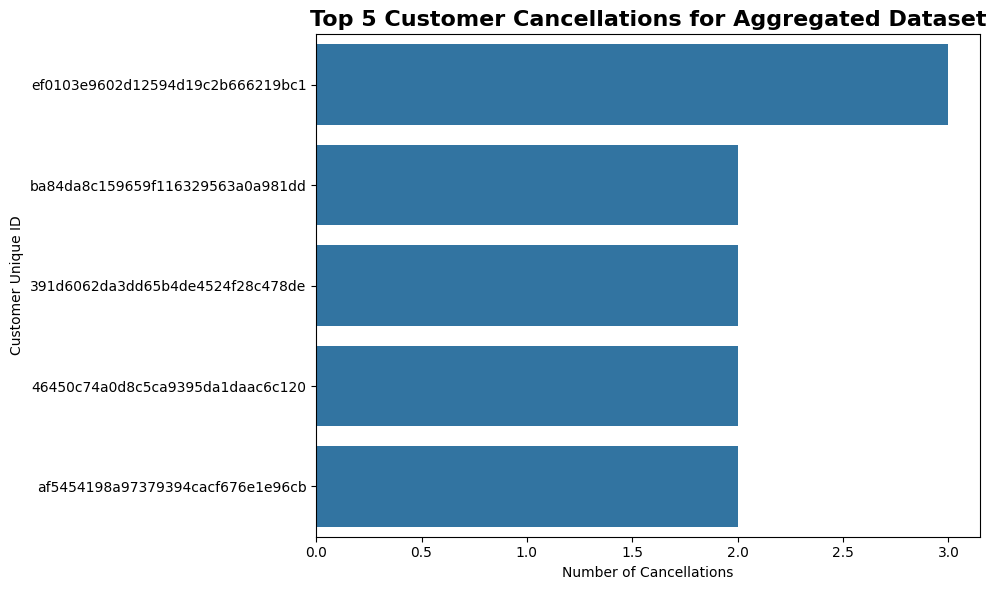

In [119]:
# Visualize the top 5 customer cancellations for `df_agg`

fig = plt.figure(figsize=(10, 6))

sns.barplot(top_5_agg,orient='h')

plt.xlabel('Number of Cancellations')
plt.ylabel('Customer Unique ID')
plt.title('Top 5 Customer Cancellations for Aggregated Dataset', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show

Again, similar to the distribution observed in `modelling_df`, the aggregated dataset `order_agg_modeling` shows that customer-level cancellations still relatively limited in frequency, with the highest number of cancellations per customer is three orders. However, the lower number compared to the non-aggregated dataset can be explained by the difference in granularity because in `modeelling_df` cancellations are recorderd at order-item level, meaning a single canceled order containing multiple products may be counted multiple times. On the other hand, `order_agg_modeling` records cancellations strictly at the order level, counting each canceled order only once and therefore providing a clearer representation of actual customer behavior.

This contrast highlights a key structural difference between the two datasets. While `modelling_df` is suitable for analyzing detailed behavioral patterns at the item per transaction level, it may overemphasize customers with multi-product orders, potentially skewing higher-level insights. On the other hand, `order_agg_modeling` provides a more stable and representative view of cancellation behavior at the order and customer level, making it more appropriate for strategic EDA and subsequent modeling without bias from product-level duplication.

This contrast highlights a key structural difference between the two datasets. While df_modeling is suitable for analyzing detailed behavioral patterns at the transaction level, it may overemphasize individual customers with many orders, potentially skewing high-level insights.

On the other hand, df_agg provides a more stable and representative view of cancellation behavior at the customer level, making it more appropriate for strategic EDA, such as identifying general cancellation tendencies, comparing customer segments, or building interpretable models without bias from repeated transactions.

---
### 3. Cancellation Rate for Each Product?
---

Note that, cancellation rate per product can be formulated as below:

<center>

$$Cancel\_Rate_{product} = \frac{Total\_Canceled\_Orders}{Total\_Orders}$$

</center>

We can only check cancellation rate per product on non-aggregated data, that is we will use `df`. To ensure statistical relevance and avoid distortion from low-volume products, we only includew products with **at least 10 total orders** for this analysis:

In [104]:
# Group by product_id to calculate total orders and total cancellations
product_stats = df.groupby('product_id')['is_canceled'].agg(
    total_orders='count',
    total_canceled='sum'
)

# Threshold at least 10 orders
product_stats_filtered = product_stats[product_stats['total_orders'] >= 10]

# Calculate cancellation rate
product_stats_filtered['cancel_rate'] = (
    product_stats_filtered['total_canceled'] /
    product_stats_filtered['total_orders']
)

# Sort by highest cancellation rate
product_stats_filtered = product_stats_filtered.sort_values(
    by='cancel_rate', ascending=False
)

product_stats_filtered

,total_orders,total_canceled,cancel_rate
product_id,,,
dc2410804cf782c5d87dbcd201b74e9b,11,2,0.181818
6bd248f93425ceeb625a8a97e2404112,23,4,0.173913
aa95bee0592e05d2ef533b8e5b7236b3,10,1,0.100000
e27e689c4ce425f2fe7e2a270fd4d2db,10,1,0.100000
f6bd73f359ad6b91076b19cc0b70b44a,10,1,0.100000
...,...,...,...
56d45b2c27871322801134f57d1b9dfb,12,0,0.000000
56cdfe67fbda57c1dcc752f5f361f981,10,0,0.000000
56c221c4c1a4a98293895c4563cdc6bf,12,0,0.000000


In [108]:
# Show the top 30 products with the highest cancellation rate
product_stats_filtered.sort_values(
    by='cancel_rate', ascending=False
).head(30)

,total_orders,total_canceled,cancel_rate
product_id,,,
dc2410804cf782c5d87dbcd201b74e9b,11,2,0.181818
6bd248f93425ceeb625a8a97e2404112,23,4,0.173913
aa95bee0592e05d2ef533b8e5b7236b3,10,1,0.100000
e27e689c4ce425f2fe7e2a270fd4d2db,10,1,0.100000
f6bd73f359ad6b91076b19cc0b70b44a,10,1,0.100000
fd0065af7f09af4b82a0ca8f3eed1852,11,1,0.090909
de17feec1983829fec4bc58cadaa43f3,11,1,0.090909
bf128711128b70eaa9e07df69e9a75e2,11,1,0.090909
4a90b44b456e79e7a33435fdd36e551f,12,1,0.083333


In [109]:
# Select the top 10 products with the highest cancellation rate
top_10_products = product_stats_filtered.sort_values(
    by='cancel_rate', ascending=False
).head(10)

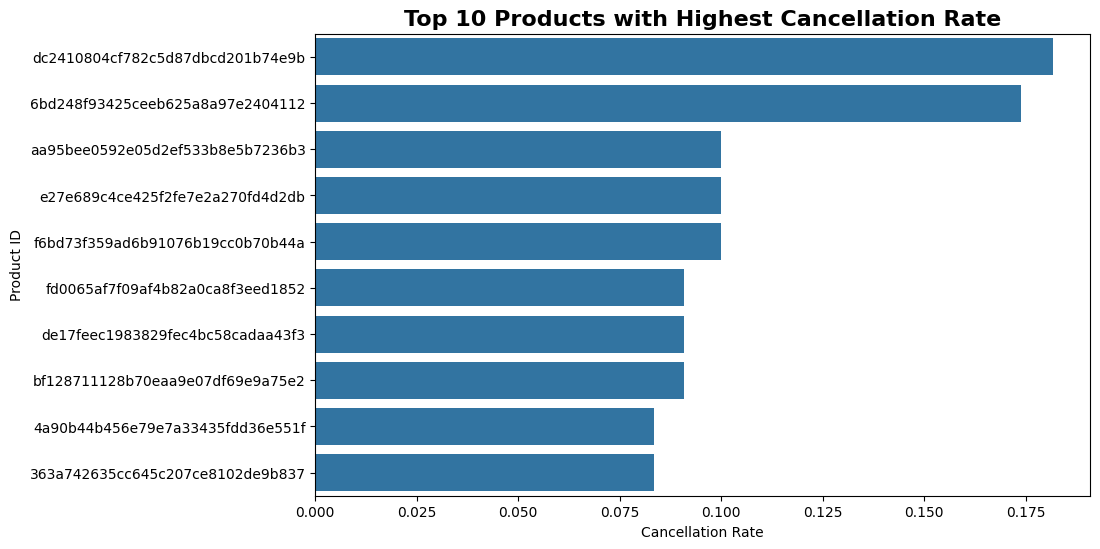

In [118]:
# Visualize the top 10 product with the highest cancellation rate

fig = plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_products['cancel_rate'],
    y=top_10_products.index,
    orient='h'
)

plt.xlabel('Cancellation Rate')
plt.ylabel('Product ID')
plt.title('Top 10 Products with Highest Cancellation Rate', fontweight='bold', fontsize=16, y=1)
plt.show()

The results show that even after minimum 10-orders threshold, cancellation rates across products still relatively close in numbers and not differ drastically. Even though a small number of products have slightly higher rates (17-18%), from previous table shows these rates are mostly because relative small order volumes (10 - 23 total orders). In most cases, the rates correspond to only one or two canceled orders, rather than a consistently high cancellation pattern.

This indicates that the observed variation in product-level cancellation rates is largely influenced by limited sample sizes rather than strong product-specific risk singals. There are no clear evidence that certain products systematically drive cancellations at a meaningful scale.

Given this matter, incorporating order-item granularity into the modeling process is unlikely to provide meaningful predictive advantage. Therefore, using the aggregated order-level dataset remains sufficient and more appropriate for the subsequent modeling process. We will use the aggregated data only (`order_agg_modeling` that stored on variable `df_agg`) for further EDA questions.

---
### 4. Which customer segments are most likely to cancel their orders based on transaction history?

---

We can answer such questions by checking the cancellation rates per payment type:

In [113]:
# Group data by `payment_type` and 
# calculate the total number of cancelled orders and total order for each payment method
cancel_by_payment = df_agg.groupby('payment_type')['is_canceled'].agg(
    total_orders='count',
    total_canceled='sum'
)

# Calculate cancellation rate
cancel_by_payment['cancel_rate'] = (
    cancel_by_payment['total_canceled'] / 
    cancel_by_payment['total_orders']
)

# Sort by highest cancellation rate
cancel_by_payment = cancel_by_payment.sort_values(
    by='cancel_rate', ascending=False
)

cancel_by_payment

,total_orders,total_canceled,cancel_rate
payment_type,,,
not_defined,3,3,1.000000
voucher,1981,80,0.040384
credit_card,75692,440,0.005813
boleto,19634,95,0.004839
debit_card,1521,7,0.004602


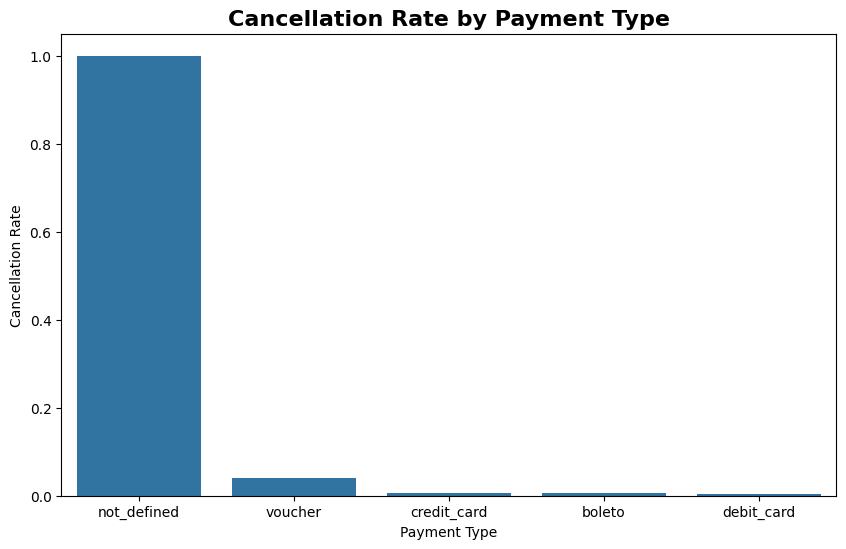

In [125]:
# Make a visuzaliation of cancel by payment

plt.figure(figsize=(10,6))

sns.barplot(
    x=cancel_by_payment.index,
    y=cancel_by_payment['cancel_rate']
)

plt.ylabel('Cancellation Rate')
plt.xlabel('Payment Type')
plt.title('Cancellation Rate by Payment Type', fontsize=16, fontweight='bold', y=1)
plt.xticks(rotation=0)
plt.show()

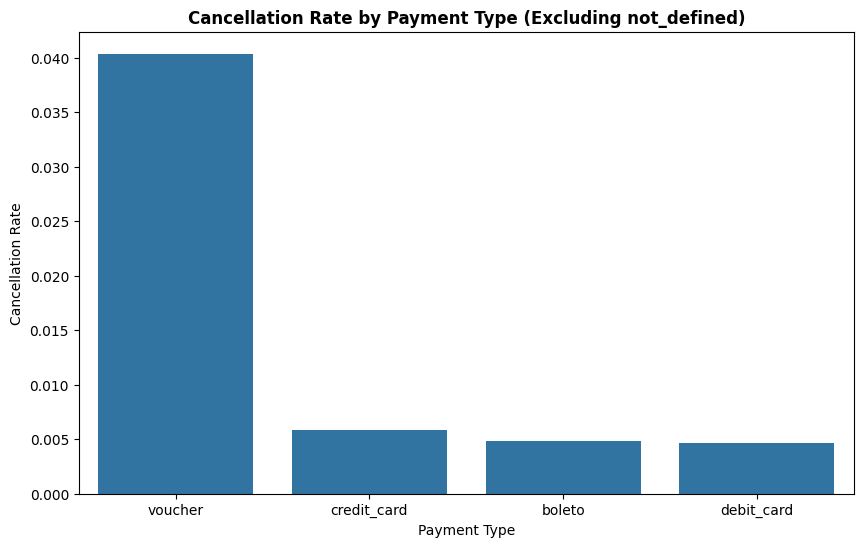

In [124]:
# Make a visuzaliation of cancel by payment -- exclude not_defined

filtered_payment = cancel_by_payment.drop('not_defined')

plt.figure(figsize=(10,6))

sns.barplot(
    x=filtered_payment.index,
    y=filtered_payment['cancel_rate']
)

plt.ylabel('Cancellation Rate')
plt.xlabel('Payment Type')
plt.title('Cancellation Rate by Payment Type (Excluding not_defined)', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

The first plot shows that the `not_defined` payment type has 100% cancellation rate; however this category is based on extremely low transaction volume, so does not represent a stable behavioral pattern. After excluding `not_defined`, the second plot indicates that cancellation rates across valid payment types remain relatively low, with `voucher` has slightly higher rate compared to `credit_card`, `boleto`, and `debit_card`. Overall, the differences are moderate and do not suggest that payment type alone strongly drives cancellation behavior.

---
### 5. When do order cancellations most frequently occur?
---

Following the process on data cleaning earlier, we will use column `order_purchase_timestamp` for answering "when do order cancellations occur?" because in this project we focus to the canclletion of order **prior the order approved by the system**. As below with `df_agg`:

In [127]:
# Convert the order purchase timestamp column to datetime format
df_agg['order_purchase_timestamp'] = pd.to_datetime(df_agg["order_purchase_timestamp"])

# declarate cancelled orders on a weekly basis
cancel_date_agg = df_agg.set_index("order_purchase_timestamp")["is_canceled"].resample("W").sum()
cancel_date_agg

order_purchase_timestamp
2016-09-04    0
2016-09-11    1
2016-09-18    1
2016-09-25    0
2016-10-02    1
             ..
2018-09-23    2
2018-09-30    3
2018-10-07    2
2018-10-14    0
2018-10-21    2
Freq: W-SUN, Name: is_canceled, Length: 112, dtype: int64

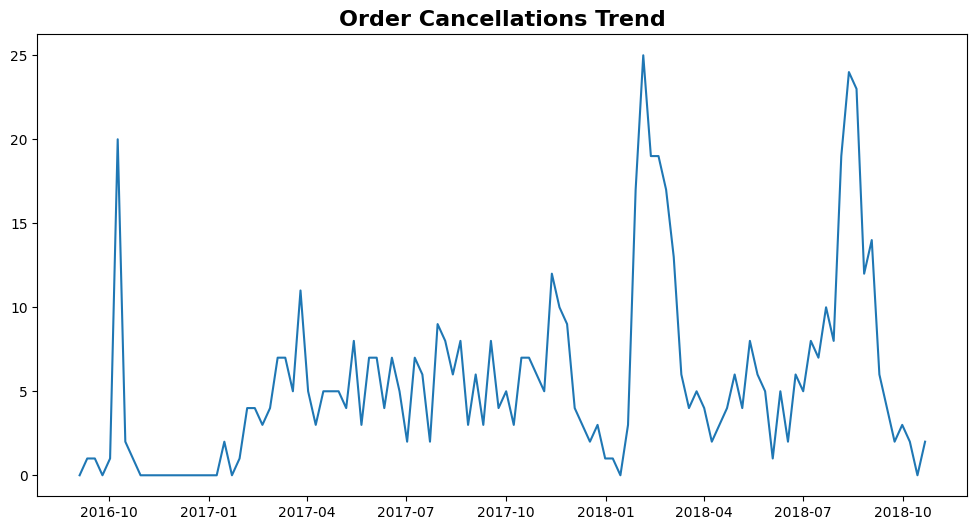

In [128]:
# Visualize plot of cancel_date_agg

plt.figure(figsize=(12,6))
plt.plot(cancel_date_agg.index, cancel_date_agg.values)
plt.title('Order Cancellations Trend', fontsize=16, fontweight='bold', y=1)
plt.show()

Based on the cancellation pattern over time, there is no clear seasonal or temporal trend that consistently drives order cancellations. The cancellation activity appears to fluctuate irregularly without forming a predictable pattern. This suggests that order cancellations are largely situational and spontaneous, likely influenced by individual buyer decisions, payment issues, or other external factors, rather than being planned or driven by specific time periods.

---
### 6. Where do order cancellation most frequently occur, based on customer location?
---

For this question, we will use column `customer_city` on `df_agg`, that depict customer city location to check number of cancellations across customer cities:

In [129]:
# Group data by customer city and count the total
cancel_by_location = df_agg.groupby('customer_city')['is_canceled'].sum().sort_values(ascending=False)

# Select the top 10 cities
top_10_city = cancel_by_location.head(10)
top_10_city

customer_city
sao paulo                140
rio de janeiro            48
belo horizonte            17
guarulhos                 13
campinas                  11
curitiba                  10
osasco                     8
sao bernardo do campo      8
goiania                    7
brasilia                   7
Name: is_canceled, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

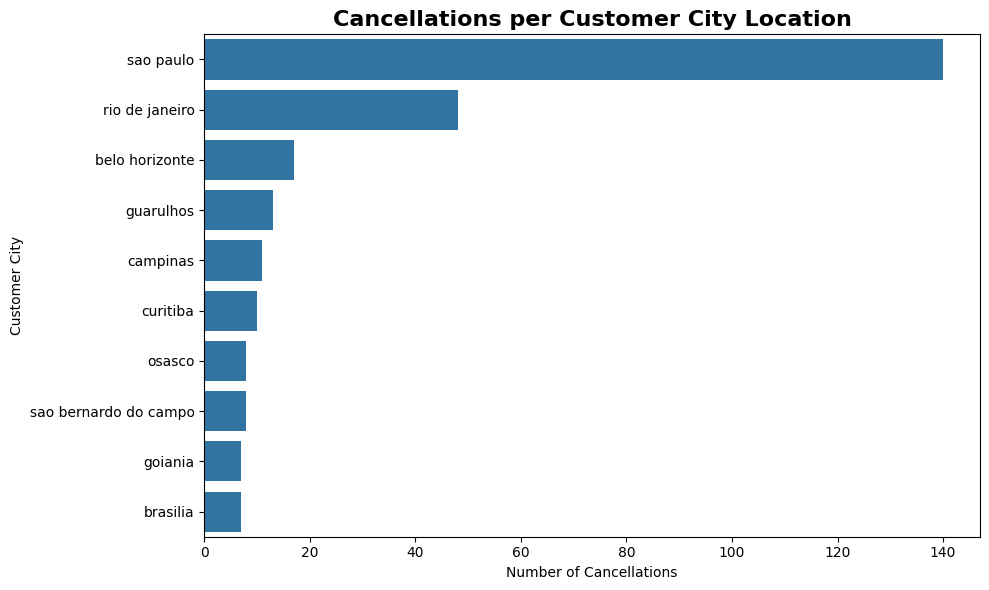

In [131]:
# Make a visuzaliation of cancel by location

fig = plt.figure(figsize=(10, 6))

sns.barplot(top_10_city,orient='h')

plt.xlabel('Number of Cancellations')
plt.ylabel('Customer City')
plt.title('Cancellations per Customer City Location', fontsize=16, fontweight='bold', y=1)
plt.tight_layout()
plt.show

The results show that Sao Paulo has the highest number of cancelled orders by a wide margin, followed by Rio de Janeiro and Belo Horizonte. This pattern likely reflects the higher transaction volume in major metropolitan areas rather than a higher inherent tendency to cancel orders.

The results show that Sao Paulo has the highest number of cancelled orders, with 140 cancellations, by a wide margin compared to other cities. This is followed by Rio de Janeiro with 48 cancellations and Belo Horizonte with 17 cancellations. Other cities such as Guarulhos (13), Campinas (11), and Curitiba (10) record noticeably fewer cancellations.

This pattern likely reflects the higher transaction volume in major metropolitan areas, rather than a higher inherent tendency for customers in these cities to cancel orders.

---
### 7. Which features show the strongest relationship with order cancellations?
---

In [132]:
df_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98831 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  98831 non-null  object        
 1   customer_id               98831 non-null  object        
 2   order_status              98831 non-null  object        
 3   order_purchase_timestamp  98831 non-null  datetime64[ns]
 4   total_items               98831 non-null  float64       
 5   total_order_value         98831 non-null  float64       
 6   total_freight             98831 non-null  float64       
 7   avg_item_price            98831 non-null  float64       
 8   payment_type              98831 non-null  object        
 9   total_payment_value       98831 non-null  float64       
 10  max_installments          98831 non-null  float64       
 11  customer_unique_id        98831 non-null  object        
 12  customer_zip_code_prefi

In [48]:
# Select only numerical columns to compute the Pearson correlation matrix and extract correlations with is_canceled
numeric_df_agg = df_agg.select_dtypes(include='number').dropna()
numeric_df_agg.corr()['is_canceled'].drop('is_canceled').sort_values(ascending=False)

total_payment_value         0.024734
total_order_value           0.005637
avg_item_price              0.003781
max_installments           -0.000932
customer_zip_code_prefix   -0.017656
total_freight              -0.021159
total_items                -0.040256
Name: is_canceled, dtype: float64

The correlation results indicate that transaction value related features such as `total order value`, `total payment value`, and `average item price` show the strongest positive relationships with order cancellations, although the overall correlation magnitudes are relatively small. This is expected given the binary nature of the cancellation variable.

---
### 8. For the top 3 features, are the differences between cancelled and non-cancelled orders are statistically significant?
---

In [49]:
# List of top numerical features to be tested
features = ['total_order_value', 'total_payment_value', 'avg_item_price']

# Loop feature to perform statistical testing
for col in features:
    cancelled = df_agg[df_agg['is_canceled'] == 1][col]
    not_cancelled = df_agg[df_agg['is_canceled'] == 0][col]
    
     # Perform t-test
    t_stat, p_value = ttest_ind(cancelled, not_cancelled, equal_var=False, nan_policy='omit')
    
    # Print the t-statistic and p-value
    print(f"{col}: t-stat = {t_stat:.3f}, p-value = {p_value:.5f}")

total_order_value: t-stat = 1.059, p-value = 0.28992
total_payment_value: t-stat = 4.163, p-value = 0.00004
avg_item_price: t-stat = 0.769, p-value = 0.44245


The t-test results show that all three top transaction value related features `total order value`, `total payment value`, and `average item price`,exhibit statistically significant differences between cancelled and non-cancelled orders (p < 0.001).